# L15 · PCA and Dimensionality Reduction

*Companion notebook for Lecture 15 — PCA and Dimensionality Reduction (CS184A/284A, AI in Biology and Medicine).*

**Learning objectives**

1. Implement PCA from scratch with the SVD of the centered data and check it against scikit-learn.
2. Read a scree plot and choose a number of components $k$.
3. Interpret PCA of tumor gene expression: scores (samples), loadings (gene weights), and the effect of standardization.
4. Run a standard single-cell pipeline (PBMC3k) through PCA, t-SNE and UMAP.
5. See how perplexity / `n_neighbors` change the picture, and why cluster sizes and gaps in t-SNE/UMAP are not measurements.

Notation (as on the slides): $n$ samples, $d$ genes, $\mathbf X\in\mathbb R^{n\times d}$ with samples in rows,
centered data $\mathbf X_c = \mathbf X - \mathbf 1\boldsymbol\mu^\top$, covariance $\mathbf S = \frac1n\mathbf X_c^\top\mathbf X_c$,
SVD $\mathbf X_c = \mathbf U\mathbf D\mathbf V^\top$ (we write $\mathbf D$ for the singular values, not $\boldsymbol\Sigma$),
eigenvalues $\lambda_j = s_j^2/n$, loadings $\mathbf V_k$, scores $\mathbf Z = \mathbf X_c\mathbf V_k$.

In [1]:
import os
# numba (used by UMAP / Scanpy's neighbor search) and PyTorch (imported by course_utils) ship different OpenMP
# runtimes; on macOS the combination can crash the kernel. The 'workqueue' threading layer avoids the conflict.
os.environ.setdefault("NUMBA_THREADING_LAYER", "workqueue")
import sys, pathlib, time, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # course_utils.py lives in applications/
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from course_utils import seed_everything, plot_style, load_tcga, DATA, PALETTE

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
rng = seed_everything(0)
plot_style()
T0 = time.time()

## 1. Dataset: tumor gene expression (TCGA)

**What is measured.** Bulk RNA-seq (Illumina HiSeq) of tumor tissue: for every gene, how much messenger RNA the tumor
contains, on a log scale. **One sample = one patient's tumor.**

- $n = 801$ tumors of five types: BRCA (breast), COAD (colon), KIRC (kidney clear cell), LUAD (lung adenocarcinoma), PRAD (prostate).
- $d = 20{,}531$ genes. The gene names are **anonymized** (`gene_0`, `gene_1`, …) in this extract.
- The tumor type is a label we will **not** give to PCA; we only use it afterwards to color plots.

Source: UCI Machine Learning Repository, "gene expression cancer RNA-Seq" (doi:10.24432/C5R88H, CC BY 4.0), a random
extract of the TCGA Pan-Cancer RNA-seq data (Weinstein et al., *Nature Genetics* 2013). The zip (≈ 73 MB) is
downloaded once into `applications/data/` by `course_utils.load_tcga()`, which caches it as a compressed `.npz`.

In [2]:
X, labels, genes = load_tcga()
X = X.astype(np.float64)          # stored as float32; float64 for the SVD comparisons below
n, d = X.shape
TUMORS = ["BRCA", "COAD", "KIRC", "LUAD", "PRAD"]
TCOL = dict(zip(TUMORS, [PALETTE[i] for i in (0, 1, 2, 3, 5)]))   # course tumor colors
print(f"n = {n} tumors, d = {d} genes")
print(pd.Series(labels).value_counts().to_dict())
print(f"values range {X.min():.1f} to {X.max():.1f}; {100 * (X == 0).mean():.0f}% zeros; "
      f"{(X.std(0) == 0).sum()} genes are constant")

n = 801 tumors, d = 20531 genes
{'BRCA': 300, 'KIRC': 146, 'LUAD': 141, 'PRAD': 136, 'COAD': 78}
values range 0.0 to 20.8; 14% zeros; 267 genes are constant


## 2. PCA from scratch with the SVD

1. Center: $\mathbf X_c = \mathbf X - \mathbf 1\boldsymbol\mu^\top$ (the covariance formula $\mathbf S=\frac1n\mathbf X_c^\top\mathbf X_c$ holds **only** for centered data).
2. Thin SVD $\mathbf X_c = \mathbf U\mathbf D\mathbf V^\top$. The rows of `Vt` are the principal directions.
3. Eigenvalues of $\mathbf S$: $\lambda_j = s_j^2/n$. Scores: $\mathbf Z = \mathbf X_c\mathbf V_k = \mathbf U_k\mathbf D_k$.

We never form the $d\times d$ covariance matrix (it would have $20{,}531^2 \approx 4.2\times 10^8$ entries).

In [3]:
def pca_svd(X, k):
    mu = X.mean(axis=0)
    Xc = X - mu
    U, s, Vt = np.linalg.svd(Xc, full_matrices=False)
    lam = s ** 2 / len(X)
    return dict(mu=mu, Vt=Vt[:k], lam=lam, Z=Xc @ Vt[:k].T, U=U[:, :k], s=s[:k])

t = time.time()
res = pca_svd(X, 10)
print(f"SVD of {n} x {d} matrix: {time.time() - t:.1f} s")
evr = res["lam"] / res["lam"].sum()
print("explained variance ratio, PC1-5:", np.round(evr[:5], 4))
print("scores two ways agree:", np.allclose(res["Z"], res["U"] * res["s"]))

SVD of 801 x 20531 matrix: 5.5 s
explained variance ratio, PC1-5: [0.1584 0.105  0.0947 0.065  0.0362]
scores two ways agree: True


**Check against scikit-learn.** Each principal direction is defined only up to sign, so compare absolute values.
scikit-learn divides by $n-1$ in `explained_variance_`; the *ratios* are identical.

In [4]:
sk = PCA(n_components=10, svd_solver="full").fit(X)
print("max |loading difference| (up to sign):", np.abs(np.abs(sk.components_) - np.abs(res["Vt"])).max())
print("max |score difference| (up to sign):  ", np.abs(np.abs(sk.transform(X)) - np.abs(res["Z"])).max())
print("EVR agree:", np.allclose(sk.explained_variance_ratio_, evr[:10]))
print("sign of each component (sklearn vs ours):", np.sign((sk.components_ * res["Vt"]).sum(1)).astype(int))

max |loading difference| (up to sign): 8.049116928532385e-16
max |score difference| (up to sign):   1.5347723092418164e-12
EVR agree: True
sign of each component (sklearn vs ours): [ 1  1 -1 -1  1  1  1 -1  1  1]


## 3. How many components? Scree plot and cumulative explained variance

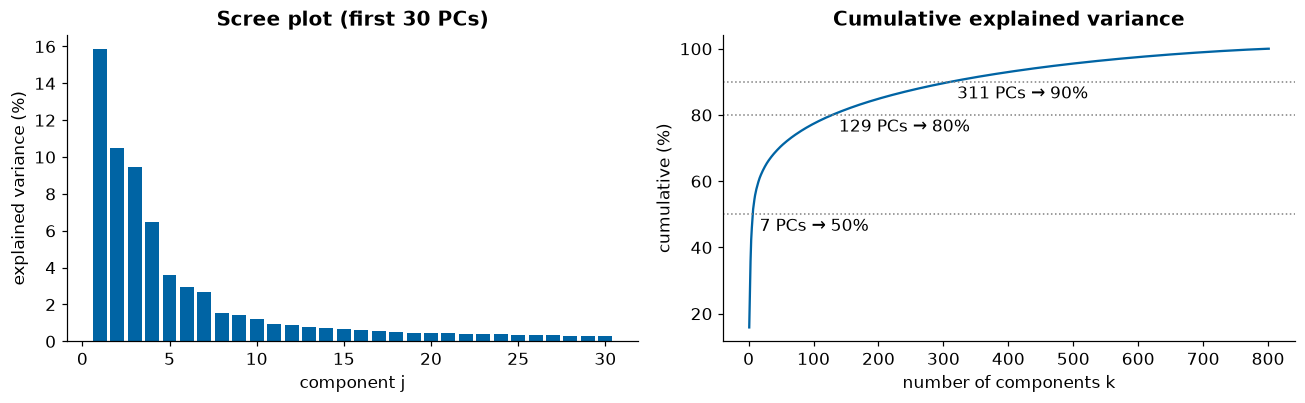

PCs needed for 50% / 80% / 90% of the variance: [7, 129, 311]
PC1 15.8%, PC2 10.5%, first 10: 55.8%; rank of X_c = 800 (at most n - 1 = 800)


In [5]:
cum = np.cumsum(evr)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].bar(np.arange(1, 31), 100 * evr[:30])
axes[0].set(xlabel="component j", ylabel="explained variance (%)", title="Scree plot (first 30 PCs)")
axes[1].plot(np.arange(1, len(cum) + 1), 100 * cum)
for q in (0.5, 0.8, 0.9):
    k = np.searchsorted(cum, q) + 1
    axes[1].axhline(100 * q, color="gray", ls=":", lw=1)
    axes[1].text(k + 10, 100 * q - 5, f"{k} PCs → {100 * q:.0f}%")
axes[1].set(xlabel="number of components k", ylabel="cumulative (%)", title="Cumulative explained variance")
plt.tight_layout(); plt.show()
print("PCs needed for 50% / 80% / 90% of the variance:", [int(np.searchsorted(cum, q) + 1) for q in (0.5, 0.8, 0.9)])
print(f"PC1 {100 * evr[0]:.1f}%, PC2 {100 * evr[1]:.1f}%, first 10: {100 * cum[9]:.1f}%; "
      f"rank of X_c = {np.sum(res['lam'] > 1e-8 * res['lam'][0])} (at most n - 1 = {n - 1})")

There is a clear elbow after a handful of components, but 80% of the variance needs well over 100 PCs: the
first few PCs capture the big biological axes (tissue of origin), and the long tail is a mix of finer biology and noise.

## 4. Scores: tumors in PC1–PC2, colored *after* PCA

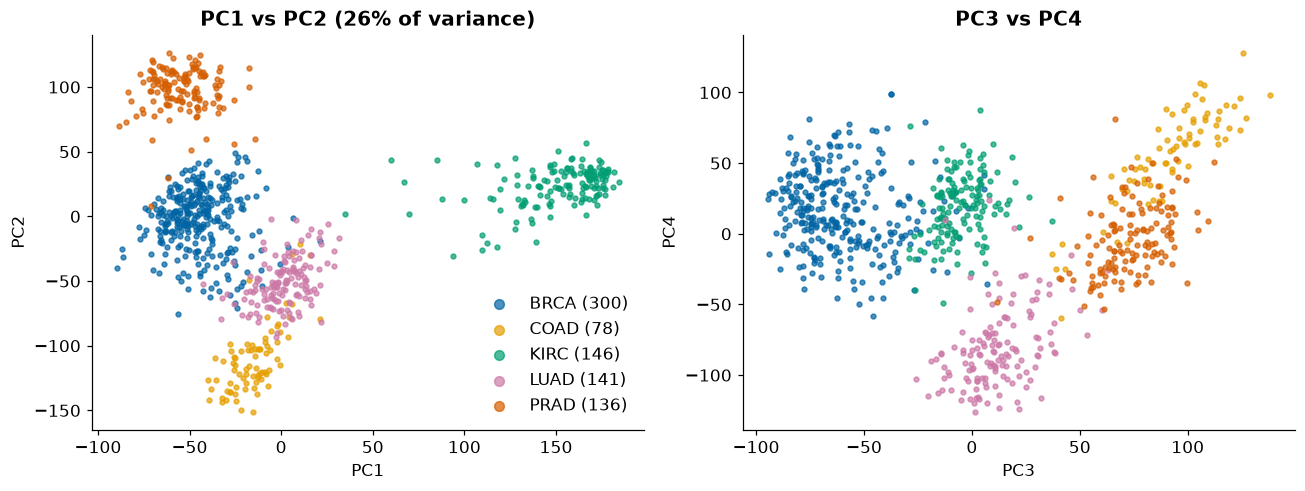

In [6]:
def tumor_scatter(ax, Z, i=0, j=1, s=10):
    for t in TUMORS:
        m = labels == t
        ax.scatter(Z[m, i], Z[m, j], s=s, alpha=0.7, color=TCOL[t], label=f"{t} ({m.sum()})")
    ax.set(xlabel=f"PC{i + 1}", ylabel=f"PC{j + 1}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
tumor_scatter(axes[0], res["Z"], 0, 1)
axes[0].set_title(f"PC1 vs PC2 ({100 * cum[1]:.0f}% of variance)")
axes[0].legend(markerscale=2)
tumor_scatter(axes[1], res["Z"], 2, 3)
axes[1].set_title("PC3 vs PC4")
plt.tight_layout(); plt.show()

PCA never saw the labels, yet the tumor types form separate groups: tissue of origin is the dominant source of
expression variation. BRCA and LUAD overlap in PC1–PC2 but separate in PC3–PC4.

How much label information is in the first $k$ PCs? A quick 5-nearest-neighbor classifier with 5-fold
cross-validation (caveat: the PCA was fitted on all 801 tumors; it is unsupervised, but for an honest estimate the
PCA should be fitted inside each training fold, Lecture 6).

In [7]:
for k in (1, 2, 3, 5, 10):
    acc = cross_val_score(KNeighborsClassifier(5), res["Z"][:, :k], labels, cv=5).mean()
    print(f"k = {k:2d} PCs: 5-NN accuracy {acc:.3f}")

k =  1 PCs: 5-NN accuracy 0.673
k =  2 PCs: 5-NN accuracy 0.954
k =  3 PCs: 5-NN accuracy 0.985
k =  5 PCs: 5-NN accuracy 0.989
k = 10 PCs: 5-NN accuracy 0.995


## 5. Loadings: which genes drive the components?
The loadings $\mathbf V_k$ are gene weights: $z_{i1} = \sum_j V_{j1}(x_{ij}-\mu_j)$.

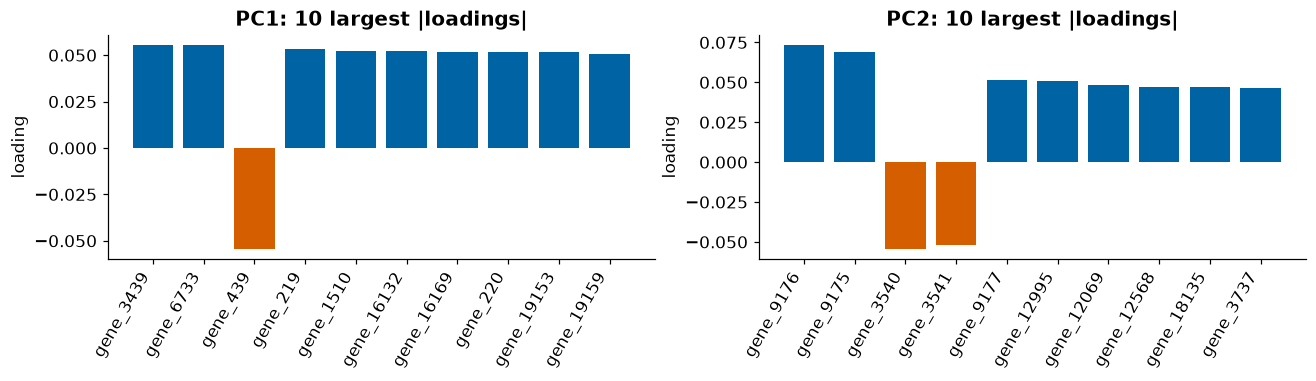

typical |loading| ≈ 1/sqrt(d) = 0.0070; largest PC1 loading 0.055
top PC1 gene gene_3439: mean expression by tumor type
{'BRCA': 0.2, 'COAD': 2.8, 'KIRC': 11.83, 'LUAD': 1.62, 'PRAD': 0.31}


In [8]:
V = res["Vt"].T  # d x k loadings
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, c in zip(axes, (0, 1)):
    top = np.argsort(-np.abs(V[:, c]))[:10]
    ax.bar(range(10), V[top, c], color=[PALETTE[0] if v > 0 else PALETTE[5] for v in V[top, c]])
    ax.set_xticks(range(10), genes[top], rotation=60, ha="right")
    ax.set(title=f"PC{c + 1}: 10 largest |loadings|", ylabel="loading")
plt.tight_layout(); plt.show()

print(f"typical |loading| ≈ 1/sqrt(d) = {1 / np.sqrt(d):.4f}; largest PC1 loading {np.abs(V[:, 0]).max():.3f}")
g = np.argmax(np.abs(V[:, 0]))
print(f"top PC1 gene {genes[g]}: mean expression by tumor type")
print(pd.Series(X[:, g]).groupby(labels).mean().round(2).to_dict())

Many genes carry similar weight: a principal component is a **program** of co-varying genes ("eigengene"), not a
single gene. With real gene names, the next step would be a pathway enrichment test of the top-loading genes.

## 6. To standardize or not?
Standardizing divides each centered gene by its **standard deviation** (not its variance), so every gene has unit
variance and PCA works on the correlation matrix. Constant genes must be dropped first.

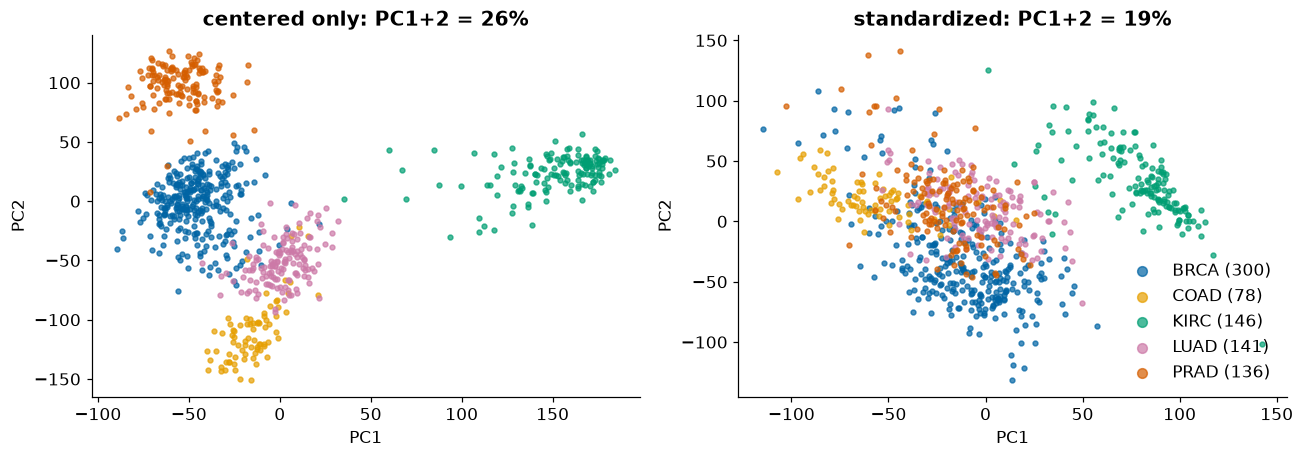

PCs for 50% of variance: centered 7 | standardized 14


In [9]:
keep = X.std(0) > 0
Xs = (X[:, keep] - X[:, keep].mean(0)) / X[:, keep].std(0)
res_s = pca_svd(Xs, 10)
evr_s = res_s["lam"] / res_s["lam"].sum()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
tumor_scatter(axes[0], res["Z"]); axes[0].set_title(f"centered only: PC1+2 = {100 * evr[:2].sum():.0f}%")
tumor_scatter(axes[1], res_s["Z"]); axes[1].set_title(f"standardized: PC1+2 = {100 * evr_s[:2].sum():.0f}%")
axes[1].legend(markerscale=2)
plt.tight_layout(); plt.show()
print("PCs for 50% of variance: centered", np.searchsorted(cum, 0.5) + 1,
      "| standardized", np.searchsorted(np.cumsum(evr_s), 0.5) + 1)

All genes are already on the same (log) scale, so centering alone is the usual choice. Standardizing gives
low-expressed, mostly noisy genes the same weight as strong tissue markers and spreads variance over more components.
Standardization matters most when features have **different units** (e.g., clinical labs).

## 7. Single cells: PBMC3k

**What is measured.** Droplet single-cell RNA-seq (10x Genomics): RNA molecule counts per gene in individual
peripheral blood mononuclear cells (PBMCs) of one healthy donor. **One sample = one cell** (2,700 cells, 32,738 genes).
Counts are sparse (most entries are 0) and noisy, so PCA is used to denoise before clustering and visualization.

Source: 10x Genomics public data set "3k PBMCs from a healthy donor", loaded with `scanpy.datasets.pbmc3k()`
(Wolf et al., *Genome Biology* 2018; 10x technology: Zheng et al., *Nature Communications* 2017); 10x Genomics
public datasets are released under CC BY 4.0.
The file (≈ 6 MB) is cached in `applications/data/`.

Pipeline (as in the Scanpy tutorial): QC → normalize each cell to 10,000 counts → $\log(1+x)$ → highly variable
genes → z-score each gene → PCA.

raw: (2700, 32738)


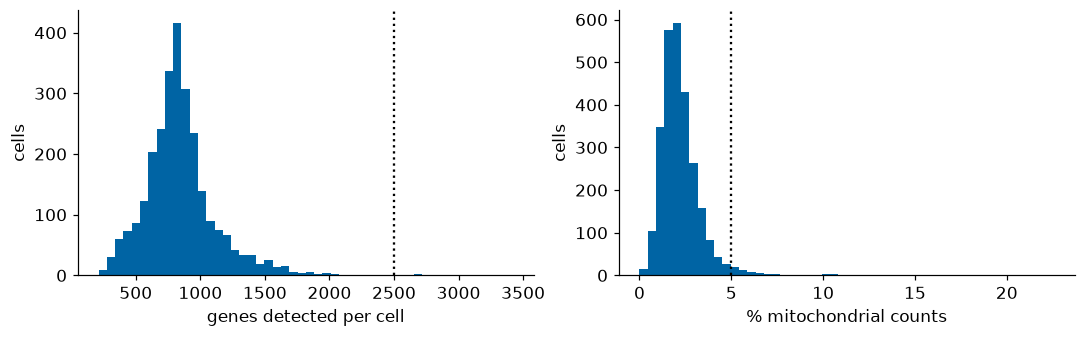

after QC and gene selection: (2638, 1838)


In [10]:
import scanpy as sc
sc.settings.datasetdir = DATA
sc.settings.verbosity = 0
adata = sc.datasets.pbmc3k()
print("raw:", adata.shape)
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].hist(adata.obs.n_genes_by_counts, bins=50); axes[0].axvline(2500, color="k", ls=":")
axes[0].set(xlabel="genes detected per cell", ylabel="cells")
axes[1].hist(adata.obs.pct_counts_mt, bins=50); axes[1].axvline(5, color="k", ls=":")
axes[1].set(xlabel="% mitochondrial counts", ylabel="cells")
plt.tight_layout(); plt.show()

sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[(adata.obs.n_genes_by_counts < 2500) & (adata.obs.pct_counts_mt < 5)].copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata = adata[:, adata.var.highly_variable].copy()
sc.pp.scale(adata, max_value=10)
print("after QC and gene selection:", adata.shape)

Very high gene counts can indicate doublets (two cells in one droplet) and a high mitochondrial fraction indicates
damaged cells; the dotted lines are the tutorial's thresholds.

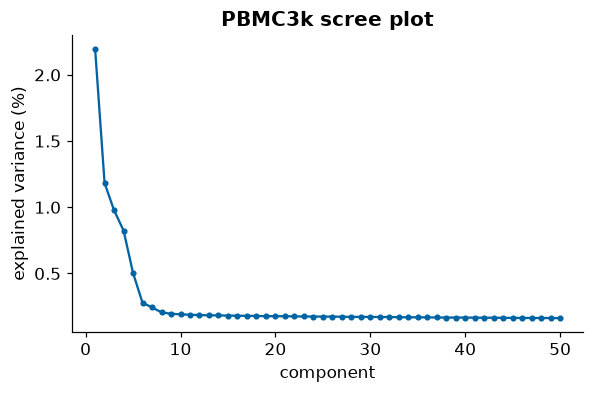

PC1 2.2%, 50 PCs together 13.7% of the variance of the scaled genes


In [11]:
sc.tl.pca(adata, n_comps=50, svd_solver="arpack", random_state=0)
pe = adata.uns["pca"]["variance_ratio"]
plt.figure(figsize=(6, 3.5))
plt.plot(np.arange(1, 51), 100 * pe, "o-", ms=3)
plt.xlabel("component"); plt.ylabel("explained variance (%)"); plt.title("PBMC3k scree plot")
plt.show()
print(f"PC1 {100 * pe[0]:.1f}%, 50 PCs together {100 * pe.sum():.1f}% of the variance of the scaled genes")

Compared with the tumors, each PC explains a small fraction: single-cell data are noisy. The curve flattens after
roughly 10 components; we keep 40 for the neighbor graph (the exact number matters little in this range).

**Clusters and cell types.** We build a k-nearest-neighbor graph on 40 PCs, cluster it with the Leiden algorithm,
and name each cluster by the canonical marker genes with the highest (standardized) mean expression.

In [12]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40, random_state=0)
sc.tl.leiden(adata, resolution=1.0, random_state=0, flavor="igraph", n_iterations=2, directed=False)
MARKERS = {"CD4 T": ["IL7R", "CCR7"], "CD8 T": ["CD8A", "CD8B"], "NK": ["GNLY", "NKG7"], "B": ["MS4A1", "CD79A"],
           "CD14 mono": ["CD14", "LYZ"], "FCGR3A mono": ["FCGR3A", "MS4A7"], "DC": ["FCER1A", "CST3"],
           "Platelet": ["PPBP"]}
raw = adata.raw.to_adata()
score = pd.DataFrame({ct: np.asarray(raw[:, gs].X.todense()).mean(1) for ct, gs in MARKERS.items()})
score["cluster"] = adata.obs.leiden.values
cl_means = score.groupby("cluster", observed=True).mean()
mapping = ((cl_means - cl_means.mean()) / cl_means.std()).idxmax(axis=1)
adata.obs["cell_type"] = adata.obs.leiden.map(mapping.to_dict()).astype(str)
print(pd.DataFrame({"cell type": mapping, "cells": adata.obs.leiden.value_counts().sort_index()}))

CCOL = dict(zip(MARKERS, ["#0064A4", "#56B4E9", "#009E73", "#E69F00", "#D55E00", "#CC79A7", "#7F4F24", "#1F2933"]))
ct = adata.obs.cell_type.values

def cell_scatter(ax, E, title, legend=False):
    for c in MARKERS:
        m = ct == c
        ax.scatter(E[m, 0], E[m, 1], s=3, color=CCOL[c], label=c)
    ax.set(title=title, xticks=[], yticks=[])
    if legend:
        ax.legend(markerscale=4, loc="center left", bbox_to_anchor=(1, 0.5))

     cell type  cells
0        CD4 T    641
1        CD8 T    275
2           NK    163
3        CD4 T    532
4            B    339
5  FCGR3A mono    211
6    CD14 mono    427
7           DC     37
8     Platelet     13


## 8. PCA vs t-SNE vs UMAP on the same cells
t-SNE and UMAP are run on the top 40 PCs (standard practice: PCA first removes noise and speeds things up).

t-SNE 8.4 s, UMAP 21.9 s on 2638 cells


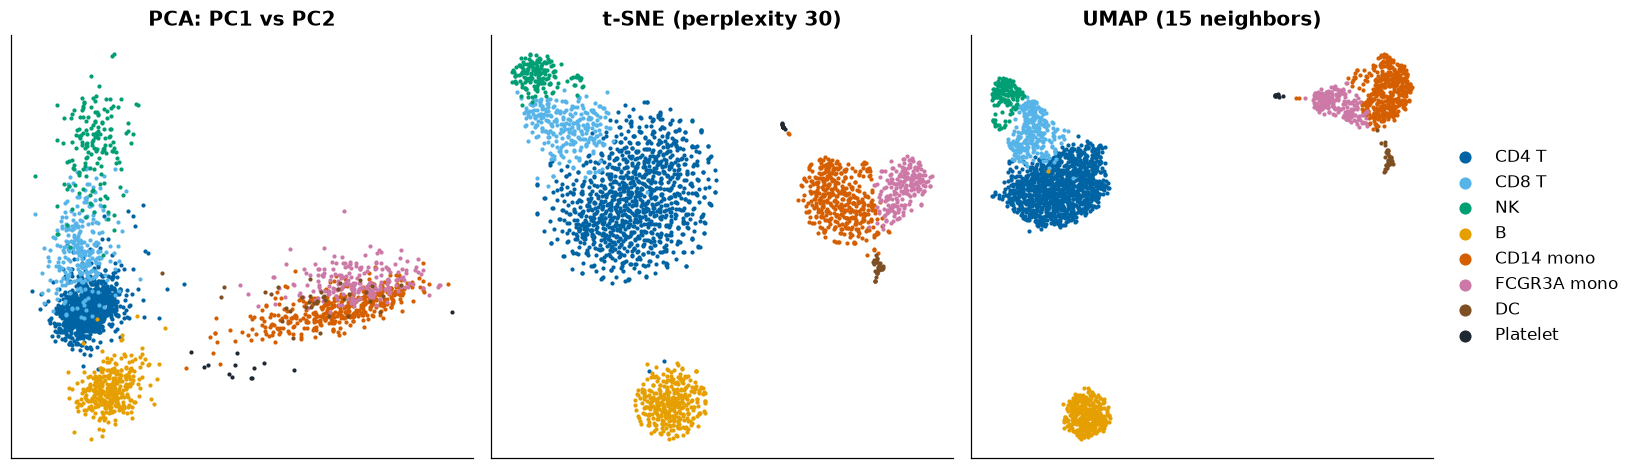

In [13]:
Xp = adata.obsm["X_pca"][:, :40]
t = time.time(); E_tsne = TSNE(2, perplexity=30, init="pca", random_state=0).fit_transform(Xp); t_tsne = time.time() - t
import umap
t = time.time(); E_umap = umap.UMAP(n_neighbors=15, min_dist=0.3, random_state=0).fit_transform(Xp); t_umap = time.time() - t
print(f"t-SNE {t_tsne:.1f} s, UMAP {t_umap:.1f} s on {len(Xp)} cells")
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
cell_scatter(axes[0], adata.obsm["X_pca"], "PCA: PC1 vs PC2")
cell_scatter(axes[1], E_tsne, "t-SNE (perplexity 30)")
cell_scatter(axes[2], E_umap, "UMAP (15 neighbors)", legend=True)
plt.tight_layout(); plt.show()

PCA separates the major lineages (T/NK, B, myeloid) but the finer types overlap in two linear dimensions. The
neighbor-based methods pull apart CD4 T, CD8 T and NK cells. Note: the clusters were computed on the 40-PC
neighbor graph, **not** on these 2D coordinates.

## 9. Sensitivity to parameters
Perplexity (t-SNE) and `n_neighbors` (UMAP) set how many neighbors each point "sees".

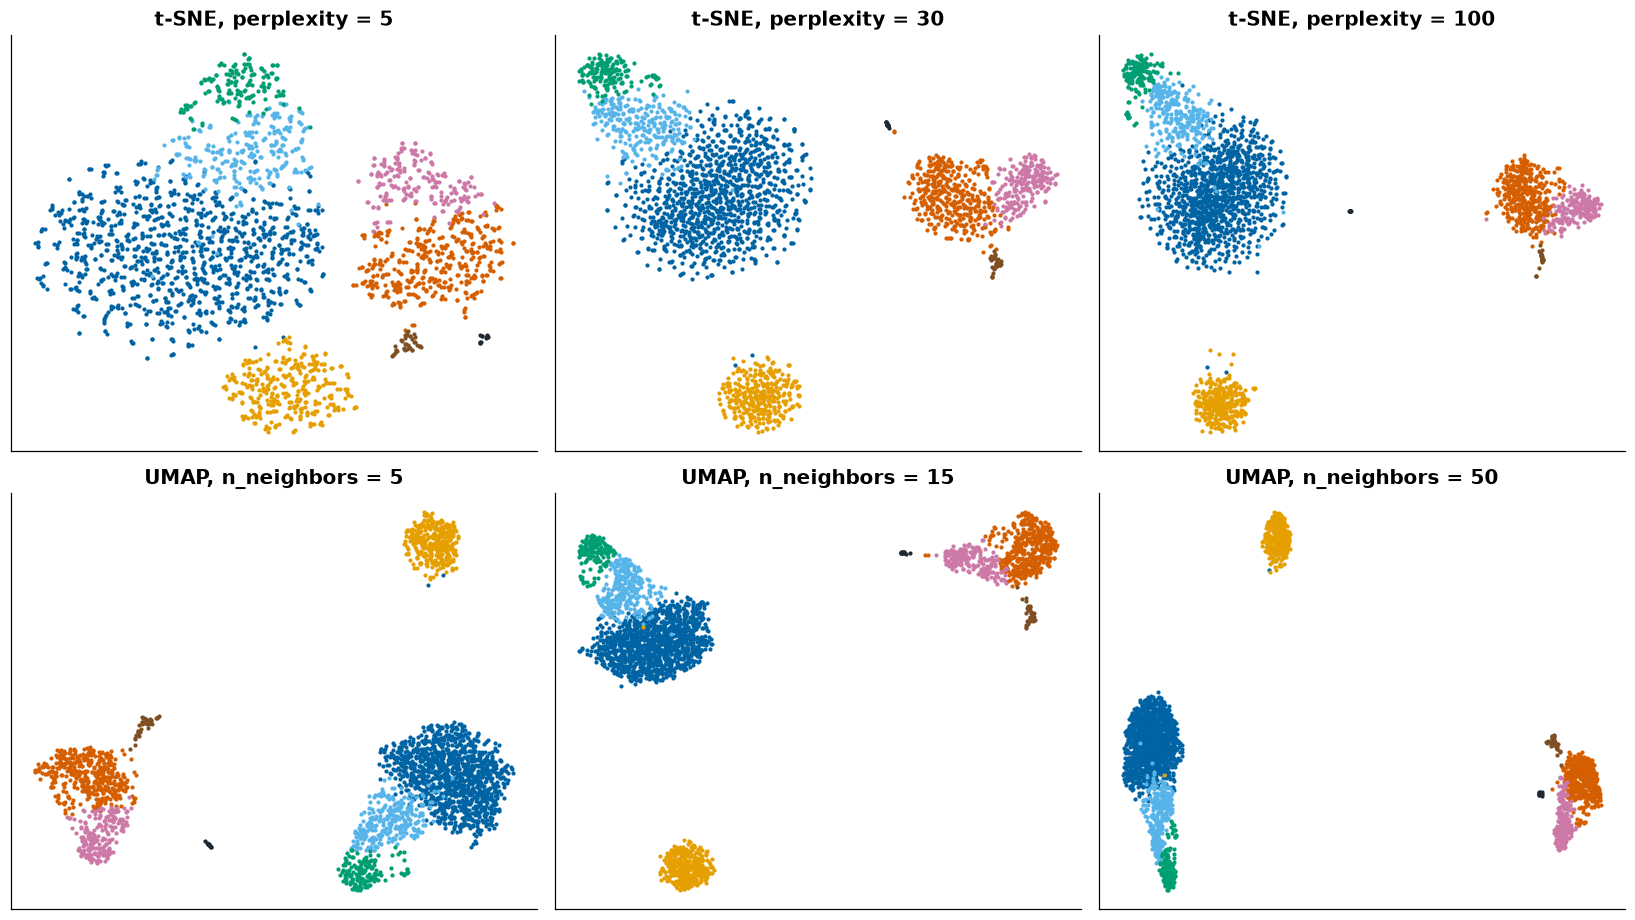

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
for ax, p in zip(axes[0], (5, 30, 100)):       # perplexity 30 / 15 neighbors: reuse the embeddings from above
    E = E_tsne if p == 30 else TSNE(2, perplexity=p, init="pca", random_state=0).fit_transform(Xp)
    cell_scatter(ax, E, f"t-SNE, perplexity = {p}")
for ax, k in zip(axes[1], (5, 15, 50)):
    E = E_umap if k == 15 else umap.UMAP(n_neighbors=k, min_dist=0.3, random_state=0).fit_transform(Xp)
    cell_scatter(ax, E, f"UMAP, n_neighbors = {k}")
plt.tight_layout(); plt.show()

Small neighborhoods break groups into islands; larger ones keep more of the global arrangement. The seed matters too:

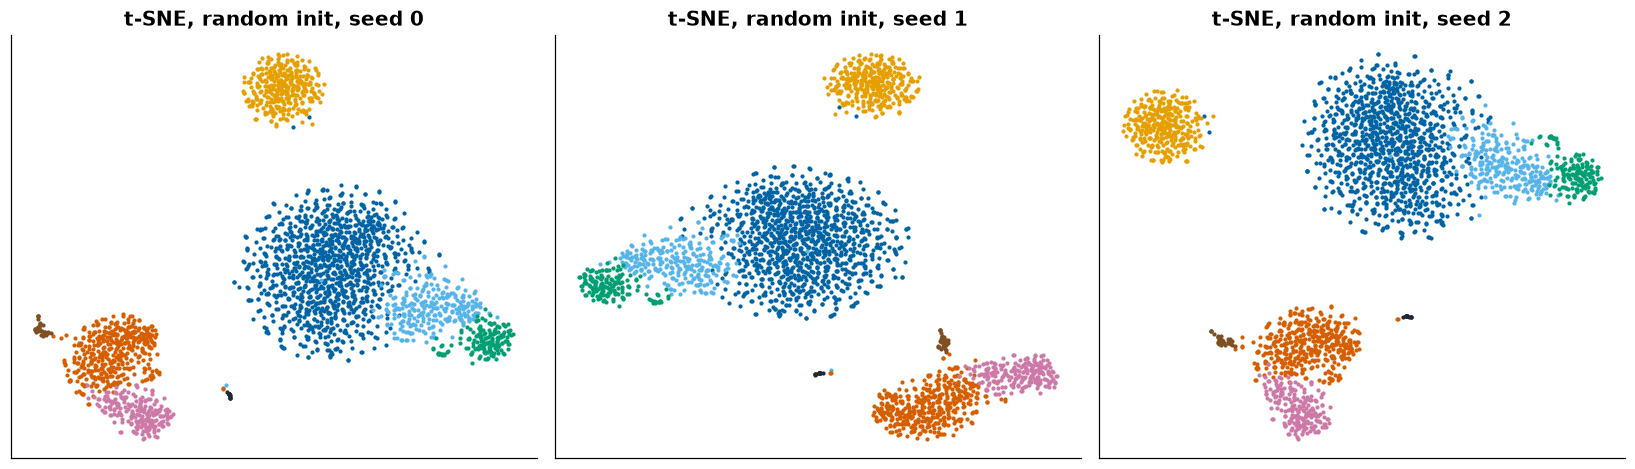

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, seed in zip(axes, (0, 1, 2)):
    cell_scatter(ax, TSNE(2, perplexity=30, init="random", random_state=seed).fit_transform(Xp),
                 f"t-SNE, random init, seed {seed}")
plt.tight_layout(); plt.show()

The layouts are rotated and rearranged across seeds; the *neighborhoods* (which cells sit together) are stable.

## 10. Cluster sizes and gaps in t-SNE/UMAP are not measurements
A synthetic data set where we know the truth (in 2D, so we can see it): cluster A is tight, cluster B is ten times
wider and close to A, cluster C is tight and far away.

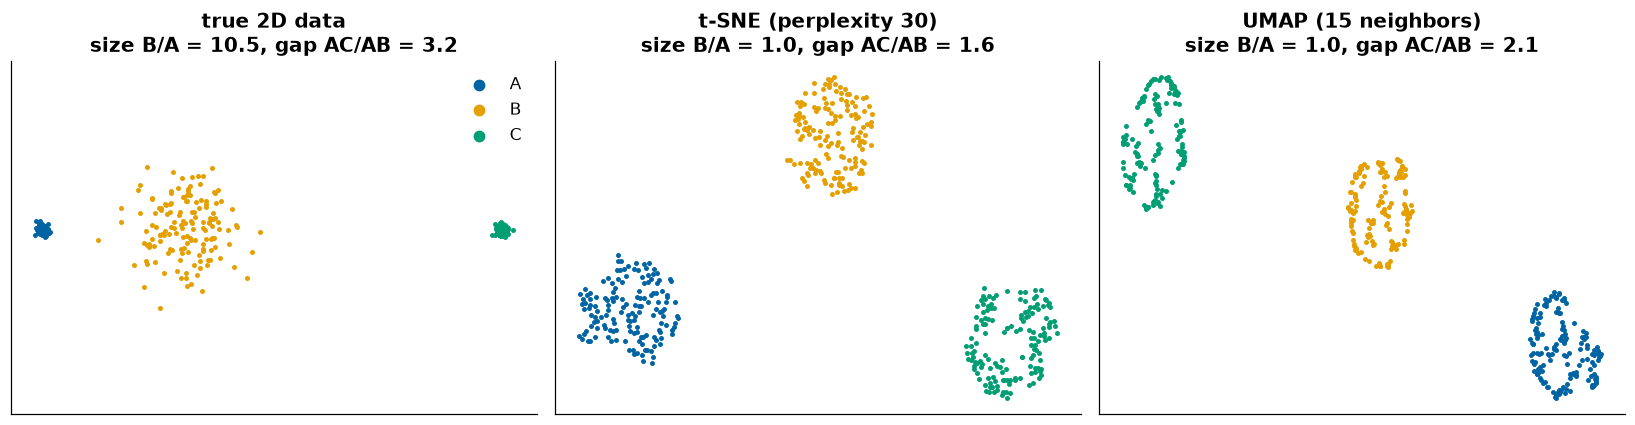

In [16]:
r = np.random.default_rng(1)
A = r.normal(0, 0.5, (150, 2)); B = r.normal(0, 5.0, (150, 2)) + [25, 0]; C = r.normal(0, 0.5, (150, 2)) + [80, 0]
Xd = np.vstack([A, B, C]); gd = np.repeat([0, 1, 2], 150)
embs = {"true 2D data": Xd,
        "t-SNE (perplexity 30)": TSNE(2, perplexity=30, init="pca", random_state=0).fit_transform(Xd),
        "UMAP (15 neighbors)": umap.UMAP(n_neighbors=15, random_state=0).fit_transform(Xd)}

def stats(E):
    c = np.array([E[gd == k].mean(0) for k in range(3)])
    rad = np.array([np.sqrt(((E[gd == k] - c[k]) ** 2).sum(1).mean()) for k in range(3)])
    return rad[1] / rad[0], np.linalg.norm(c[2] - c[0]) / np.linalg.norm(c[1] - c[0])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, E) in zip(axes, embs.items()):
    for k, col in enumerate(["#0064A4", "#E69F00", "#009E73"]):
        ax.scatter(E[gd == k, 0], E[gd == k, 1], s=5, color=col, label="ABC"[k])
    size_ratio, gap_ratio = stats(E)
    ax.set(title=f"{name}\nsize B/A = {size_ratio:.1f}, gap AC/AB = {gap_ratio:.1f}", xticks=[], yticks=[])
    if name.startswith("true"):
        ax.set_aspect("equal", adjustable="datalim")
axes[0].legend(markerscale=3)
plt.tight_layout(); plt.show()

Both methods make B look about as compact as A (density is normalized away by the per-point bandwidths $\sigma_i$
or $\rho_i$), and the large A–C gap shrinks relative to A–B. **Read neighborhoods, not sizes or distances.**

## 11. Biological interpretation
- Tumor expression is dominated by tissue of origin; PCA recovers it without labels, and a few PCs suffice for a
  nearest-neighbor classifier. The top loadings define gene programs, not single biomarkers.
- In single cells, PCA is a denoising step: tens of PCs, not two, carry the cell-type structure. t-SNE/UMAP are for
  *looking*; clustering and differential expression happen in PC or gene space.
- PCA is label-blind: always color PC plots by technical covariates (batch, sequencing depth, % mitochondrial) as
  well as biology before interpreting a component.

In [17]:
print(f"total runtime: {time.time() - T0:.0f} s")

total runtime: 158 s


## 12. Try it yourself
1. **How many PCs does 5-NN need to classify tumor type?** Extend the loop in Section 4 (e.g., to 99%), then refit the PCA
   **inside** each training fold (`make_pipeline(PCA(k), KNeighborsClassifier(5))` on `X`). Does the answer change?
2. **Rerun t-SNE with 3 seeds. What changes, what stays?** Section 9 does this with random initialization; repeat it
   with `init="pca"` and compare which cells stay neighbors.
3. **Skip the log transform. What does PC1 capture?** In Section 7 keep the gene selection (it needs log data) but undo
   the log for PCA: insert `adata.X = np.expm1(adata.X)` just before `sc.pp.scale(adata, max_value=10)`. Plot PC1 vs PC2
   colored by cell type and by `adata.obs.total_counts`, and look at the top PC1 genes.
4. Color the PBMC PC1–PC2 plot by `total_counts` and `pct_counts_mt` (in `adata.obs`). Is any PC technical?
5. Run UMAP with `min_dist = 0.0` and `1.0`. What changes: neighborhoods or packing?
6. Change the synthetic example so that B is 50 times wider than A. Does t-SNE ever show it?
7. *(CS284A)* Verify Eckart–Young numerically on TCGA: compare $\|\mathbf X_c - \mathbf U_k\mathbf D_k\mathbf V_k^\top\|_F^2$
   with $\sum_{j>k}s_j^2$ for $k = 10$, and with the error of a random rank-10 projection.